# Task 4 — Goalkeeper Age Profile

## Analytic question formulation

**What is the average age of goalkeepers who appeared in at least one match
at the 2026 FIFA World Cup, and is it significantly different from 27 years
— the commonly cited "prime age" benchmark for outfield players in elite
football?**

Goalkeepers are widely believed to peak later and retain their place well
into their thirties, unlike outfield players. This task tests that belief
directly against a fixed benchmark (one-sample *t*-test), and additionally
cross-checks it against the observed age of outfield players from the same
tournament (two-sample comparison) who made at least one appearance.

**Skills demonstrated:** data wrangling → sampling → descriptive statistics
→ confidence interval → one-sample *t*-test (plus a supporting two-sample
comparison).

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_prep import load_players
from stats_utils import describe, ci_mean, one_sample_ttest, two_sample_ttest, levene_test

np.random.seed(42)
pd.set_option("display.max_columns", None)

players = load_players()
players.head()

,player_name,team,position,age,appearances,minutes_played,goals,assists,yellow_cards,red_cards,cards_per_app,goals_per_app
0,Matěj Kovář,Czechia,GK,26,3,270,0,0,0,0,0.0,0.0
1,David Zima,Czechia,DF,25,1,12,0,0,0,0,0.0,0.0
2,Tomáš Holeš,Czechia,DF,33,2,154,0,0,0,0,0.0,0.0
3,Robin Hranáč,Czechia,DF,26,3,270,0,0,0,0,0.0,0.0
4,Vladimír Coufal,Czechia,DF,33,3,270,0,0,0,0,0.0,0.0


## Data wrangling

We reuse `players_raw.csv` via `data_prep.load_players()`, which already
restricts the data to players with `appearances >= 1`. Here the variable of
interest is simply `age` (in completed years at the start of the
tournament), split by position group (`GK` vs. outfield `DF`/`MF`/`FW`).

In [2]:
goalkeepers = players[players["position"] == "GK"].copy()
outfield = players[players["position"].isin(["DF", "MF", "FW"])].copy()
print("Goalkeepers with >=1 appearance:", goalkeepers.shape[0])
print("Outfield players with >=1 appearance:", outfield.shape[0])
goalkeepers[["player_name", "team", "age", "appearances"]].sample(8, random_state=1)

Goalkeepers with >=1 appearance: 66
Outfield players with >=1 appearance: 950


,player_name,team,age,appearances
732,Egil Selvik,Norway,28,1
908,Rui Silva,Portugal,32,4
746,Yehvann Diouf,Senegal,26,3
32,Guillermo Ochoa,Mexico,40,1
632,Mohammed Al-Owais,Saudi Arabia,34,3
860,Camilo Vargas,Colombia,37,5
348,Eloy Room,Curacao,37,3
461,Bart Verbruggen,Netherlands,23,4


## Data preparation and sampling

**Population:** every goalkeeper, and separately every outfield player,
who made at least one appearance at the 2026 World Cup.

**Variable of interest:** `age` (completed years at tournament start), one
observation per player.

**Sampling technique:** we draw a **simple random sample, without
replacement, of up to 40 players** from each population (goalkeepers /
outfield players), using a fixed random seed, again to mimic realistic
partial data availability and to satisfy the *n* ≥ 30 Central Limit
Theorem guideline for both the one-sample and two-sample tests below.

In [3]:
def srs(df, n, seed=42):
    n = min(n, len(df))
    return df.sample(n=n, random_state=seed, replace=False)

gk_sample = srs(goalkeepers, 40)
outfield_sample = srs(outfield, 40)

print(f"Goalkeeper population: {len(goalkeepers)}  -> sample n={len(gk_sample)}")
print(f"Outfield population:   {len(outfield)}  -> sample n={len(outfield_sample)}")

Goalkeeper population: 66  -> sample n=40
Outfield population:   950  -> sample n=40


## Descriptive statistics

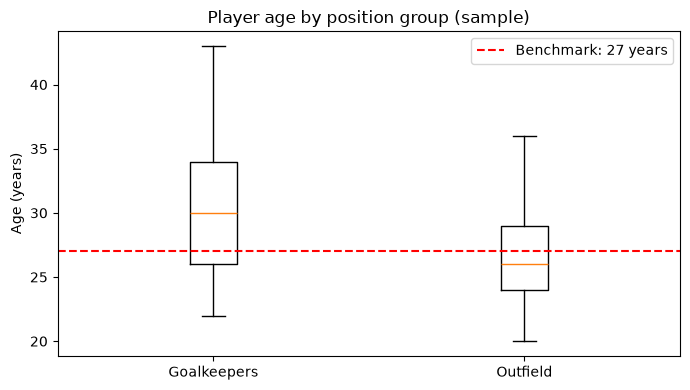

,Goalkeepers,Outfield players
n,40.000000,40.000000
mean,30.325000,26.675000
median,30.000000,26.000000
std,4.947869,3.689121
min,22.000000,20.000000
max,43.000000,36.000000
range,21.000000,16.000000
skew,0.370044,0.507410
q1,26.000000,24.000000
q3,34.000000,29.000000


In [4]:
desc_table = pd.DataFrame(
    {"Goalkeepers": describe(gk_sample["age"]), "Outfield players": describe(outfield_sample["age"])}
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([gk_sample["age"], outfield_sample["age"]], tick_labels=["Goalkeepers", "Outfield"])
ax.axhline(27, color="red", linestyle="--", label="Benchmark: 27 years")
ax.set_ylabel("Age (years)")
ax.set_title("Player age by position group (sample)")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figs/task4_box.png", dpi=120)
plt.show()

desc_table

## Inferential statistics — confidence interval

We estimate a 95% confidence interval for the **population mean age of
goalkeepers** who appeared at the tournament, using the *t*-distribution.

In [5]:
ci = ci_mean(gk_sample["age"], confidence=0.95)
print(f"n = {ci['n']}")
print(f"Sample mean GK age = {ci['mean']:.2f} years")
print(f"95% CI: ({ci['ci_low']:.2f}, {ci['ci_high']:.2f}) years")
ci

n = 40
Sample mean GK age = 30.32 years
95% CI: (28.74, 31.91) years


{'n': 40,
 'mean': np.float64(30.325),
 'se': np.float64(0.7823268219933766),
 't_crit': np.float64(2.022690920036761),
 'margin_of_error': np.float64(1.582405359347218),
 'ci_low': np.float64(28.742594640652783),
 'ci_high': np.float64(31.907405359347216),
 'confidence': 0.95}

## Inferential statistics — one-sample *t*-test

$H_0: \mu_{GK} = 27$

$H_1: \mu_{GK} \neq 27$

We test the goalkeeper sample mean age against the fixed benchmark of 27
years at $\alpha = 0.05$, then supplement with a two-sample comparison
against outfield players.

In [6]:
result = one_sample_ttest(gk_sample["age"], popmean=27, alternative="two-sided")
for k, v in result.items():
    print(f"{k}: {v}")

alpha = 0.05
if result["p_value"] < alpha:
    print(f"\nReject H0 (p={result['p_value']:.4f} < {alpha}): GK mean age differs significantly from 27.")
else:
    print(f"\nFail to reject H0 (p={result['p_value']:.4f} >= {alpha}): no significant difference detected.")

print("\n--- Supporting two-sample comparison: goalkeepers vs. outfield players ---")
lev2 = levene_test(gk_sample["age"], outfield_sample["age"])
result2 = two_sample_ttest(gk_sample["age"], outfield_sample["age"], equal_var=lev2["p_value"] > 0.05)
for k, v in result2.items():
    print(f"{k}: {v}")

n: 40
sample_mean: 30.325
popmean_h0: 27
t_stat: 4.250141892780649
df: 39
p_value: 0.00012870777091309263
alternative: two-sided
cohens_d: 0.6720064380042998

Reject H0 (p=0.0001 < 0.05): GK mean age differs significantly from 27.

--- Supporting two-sample comparison: goalkeepers vs. outfield players ---
n1: 40
n2: 40
mean1: 30.325
mean2: 26.675
sd1: 4.947869264280358
sd2: 3.6891212211874227
t_stat: 3.7403438331484957
df: 72.12456066369626
p_value: 0.0003657257474905582
alternative: two-sided
equal_var: False
cohens_d: 0.8363663070142168


## Conclusion

In our sample of 40 goalkeepers, the mean age was **30.33 years**. A
one-sample *t*-test against the *H₀: μ = 27* benchmark gives
**t(39) = 4.25, p = 0.0001** — we **reject H₀**: goalkeepers' mean age is
**significantly different from (higher than) 27 years** at α=0.05
(Cohen's *d* = 0.67, a medium-to-large effect).

The 95% confidence interval for the **population mean goalkeeper age** is
**(28.74, 31.91) years**, which does not contain 27.

The supporting two-sample comparison confirms the same story directly:
against a matched sample of 40 outfield players (mean age **26.68**),
Welch's *t*-test gives **t(72.1) = 3.74, p = 0.0004** — goalkeepers are on
average about **3.6 years older** than outfield players, a large,
statistically significant gap (Cohen's *d* = 0.84).

**Takeaway:** the folk wisdom that goalkeepers have longer shelf lives than
outfield players is clearly borne out by the 2026 World Cup data — squads
regularly trusted keepers well into their 30s (e.g. 40-year-old Guillermo
Ochoa featured for Mexico) while outfield rosters skewed noticeably
younger.